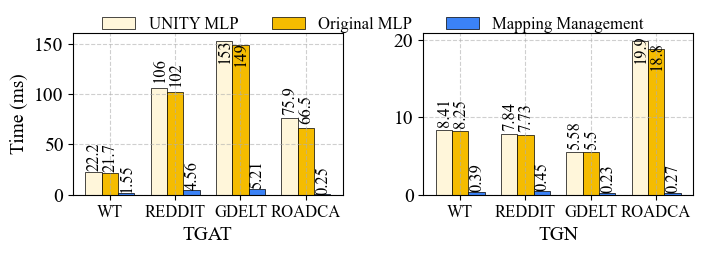

In [1]:
# 修改为 1x2 布局并确保只创建两个子图
import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
plt.rcParams['font.family'] = 'Times New Roman'
# 读取 YAML 文件
yaml_file = "overhead.yaml"
with open(yaml_file, "r") as file:
    batch_data = yaml.safe_load(file)

# 设定子图结构
fig = plt.figure(figsize=(8, 2.1))
outer_gs = gridspec.GridSpec(1, 2, wspace=0.3, hspace=0.3)

# 定义颜色方案
# colors = ['#F8F2EC', '#E4CEDC', '#5EA69C']  # 用户指定的颜色
colors = ['#FFF6da','#F5BC00','#3B82F6']
baseline_labels = ["UNITY MLP", "Original MLP", "Mapping Management"]
handles, labels = [], []

# 遍历数据集和模型进行绘图
for row_idx, (dataset, models) in enumerate(batch_data.items()):
    if row_idx >= 2:
        break  # 仅绘制两个子图
    
    ax = fig.add_subplot(outer_gs[0, row_idx])  # Correcting subplot indexing
    
    # 设定 x 轴
    batch_sizes = list(models["UNITY MLP"].keys())
    x_base = np.arange(len(batch_sizes))
    bar_width = 0.25
    
    # 绘制不同的 baseline
    for baseline_idx, baseline in enumerate(baseline_labels):
        x_offset = x_base + (baseline_idx - 1) * bar_width
        heights = [models[baseline][bs] for bs in batch_sizes]
        bars = ax.bar(x_offset, heights, width=bar_width, color=colors[baseline_idx],
                      edgecolor='black', linewidth=0.5, alpha=1, label=baseline if row_idx == 0 else "")
        
        # 添加数据标签
        for bar in bars:
            height = bar.get_height()
            label_height = height * 1.05
            if label_height > ax.get_ylim()[1]*0.8:  # 如果超出了 y 轴范围
                label_height = height * 0.85  # 将标签放在柱子顶端的下方
                
            ax.text(bar.get_x() + bar.get_width()/1.8, label_height,
                    f'{height:.3g}', ha='center', va='bottom', fontsize=12, rotation=90)
    
    # 设置子图属性
    # ax.set_title(f"{dataset}", fontsize=12)
    ax.set_xticks(x_base)
    ax.set_xticklabels(batch_sizes, rotation=0, ha='center', fontsize=12)
    ax.tick_params(axis='y', labelsize=14)
    ax.grid(True, which='both', linestyle='--', alpha=0.6)
    
    if row_idx == 1:
        ax.set_xlabel('TGN', fontsize=14)
        
    if row_idx == 0:
        ax.set_ylabel('Time (ms)', fontsize=14)
        ax.set_xlabel('TGAT', fontsize=14)

    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# 添加统一图例
unique_legend = dict(zip(labels, handles))
fig.legend(unique_legend.values(), unique_legend.keys(), loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.03), fontsize=12, frameon=False)

# 保存图像
plt.savefig('exp7.pdf', bbox_inches='tight')

# 显示图像
plt.show()
